In [7]:
#fixing data types
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'C:\Users\hp\afficionado_forecasting\data\transactions.xlsx - Transactions.csv')  

print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nFirst 5 rows:\n", df.head())
print("\nMissing values:\n", df.isnull().sum())

Shape: (149116, 11)

Column names: ['transaction_id', 'year', 'transaction_time', 'transaction_qty', 'store_id', 'store_location', 'product_id', 'unit_price', 'product_category', 'product_type', 'product_detail']

Data types:
 transaction_id        int64
year                  int64
transaction_time        str
transaction_qty       int64
store_id              int64
store_location          str
product_id            int64
unit_price          float64
product_category        str
product_type            str
product_detail          str
dtype: object

First 5 rows:
    transaction_id  year transaction_time  transaction_qty  store_id  \
0               1  2025          7:06:11                2         5   
1               2  2025          7:08:56                2         5   
2               3  2025          7:14:04                2         5   
3               4  2025          7:20:24                1         5   
4               5  2025          7:22:41                2         5   

    stor

In [8]:
print(df['unit_price'].describe())       # Any negative prices?
print(df['transaction_qty'].describe())  # Any zero or negative quantities?
print(df['store_id'].unique())           # How many stores?
print(df['product_category'].unique())   # What categories exist?

count    149116.000000
mean          3.382219
std           2.658723
min           0.800000
25%           2.500000
50%           3.000000
75%           3.750000
max          45.000000
Name: unit_price, dtype: float64
count    149116.000000
mean          1.438276
std           0.542509
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max           8.000000
Name: transaction_qty, dtype: float64
[5 8 3]
<ArrowStringArray>
[            'Coffee',                'Tea', 'Drinking Chocolate',
             'Bakery',           'Flavours',          'Loose Tea',
       'Coffee beans', 'Packaged Chocolate',            'Branded']
Length: 9, dtype: str


Revenue column added. Sample:
   transaction_id   store_location  revenue  hour
0               1  Lower Manhattan      6.0     7
1               2  Lower Manhattan      6.2     7
2               3  Lower Manhattan      9.0     7
3               4  Lower Manhattan      2.0     7
4               5  Lower Manhattan      6.2     7

Stores in dataset: <ArrowStringArray>
['Lower Manhattan', 'Hell's Kitchen', 'Astoria']
Length: 3, dtype: str
Product categories: <ArrowStringArray>
[            'Coffee',                'Tea', 'Drinking Chocolate',
             'Bakery',           'Flavours',          'Loose Tea',
       'Coffee beans', 'Packaged Chocolate',            'Branded']
Length: 9, dtype: str


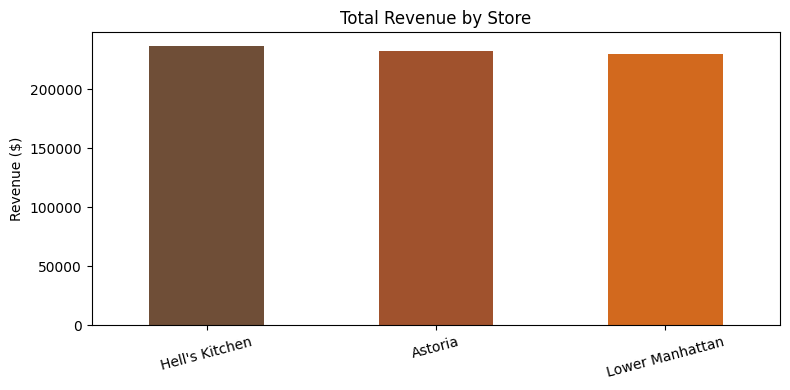

store_location
Hell's Kitchen     236511.17
Astoria            232243.91
Lower Manhattan    230057.25
Name: revenue, dtype: float64


In [9]:
df['transaction_time'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S')
df['revenue'] = df['transaction_qty'] * df['unit_price']
df['hour']        = df['transaction_time'].dt.hour
df['minute']      = df['transaction_time'].dt.minute

print("Revenue column added. Sample:")
print(df[['transaction_id','store_location','revenue','hour']].head())
print("\nStores in dataset:", df['store_location'].unique())
print("Product categories:", df['product_category'].unique())

#store comparison
store_summary = df.groupby('store_location')['revenue'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,4))
store_summary.plot(kind='bar', color=['#6F4E37','#A0522D','#D2691E'])
plt.title('Total Revenue by Store')
plt.ylabel('Revenue ($)')
plt.xlabel('')
plt.xticks(rotation = 15)
plt.tight_layout()
plt.savefig('data/store_revenue.png')
plt.show()

print(store_summary)

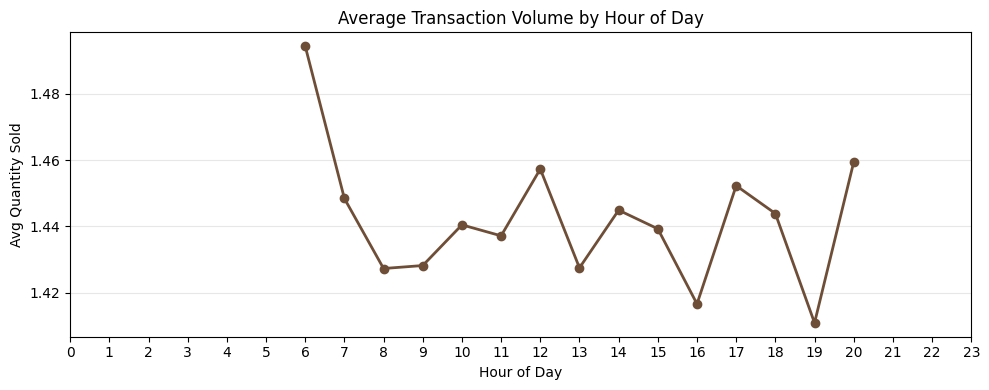

Peak hour: 6 | Value: 1.49


In [10]:
#hourly demand patterns
hourly = df.groupby('hour')['transaction_qty'].mean()

plt.figure(figsize=(10,4))
hourly.plot(kind='line', marker='o', color='#6F4E37', linewidth=2)
plt.title('Average Transaction Volume by Hour of Day')
plt.ylabel('Avg Quantity Sold')
plt.xlabel('Hour of Day')
plt.xticks(range(0,24))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('data/hourly_demand.png')
plt.show()

print("Peak hour:", hourly.idxmax(), "| Value:", round(hourly.max(), 2))

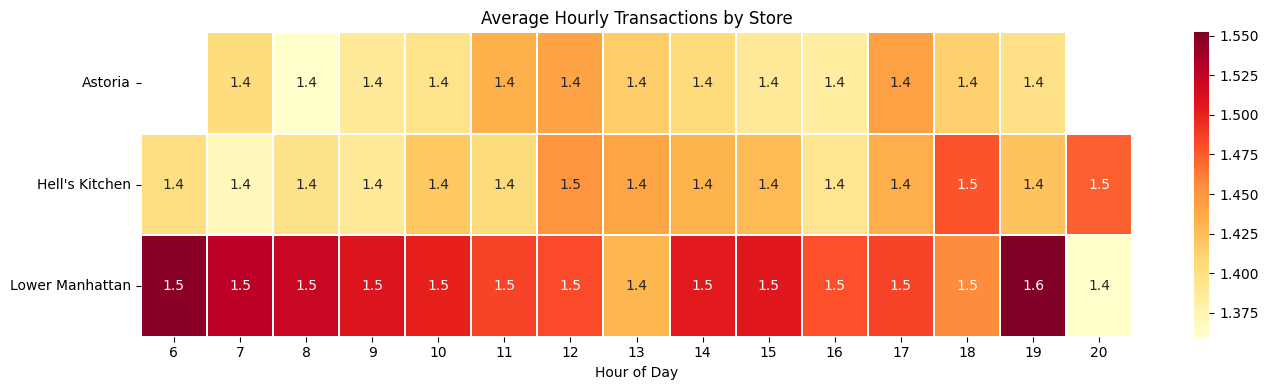

In [11]:
#store * hour heatmap
pivot = df.groupby(['store_location', 'hour'])['transaction_qty'].mean().unstack()

plt.figure(figsize=(14,4))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.1f', linewidths=0.3)
plt.title('Average Hourly Transactions by Store')
plt.ylabel('')
plt.xlabel('Hour of Day')
plt.tight_layout()
plt.savefig('data/store_hour_heatmap.png')
plt.show()

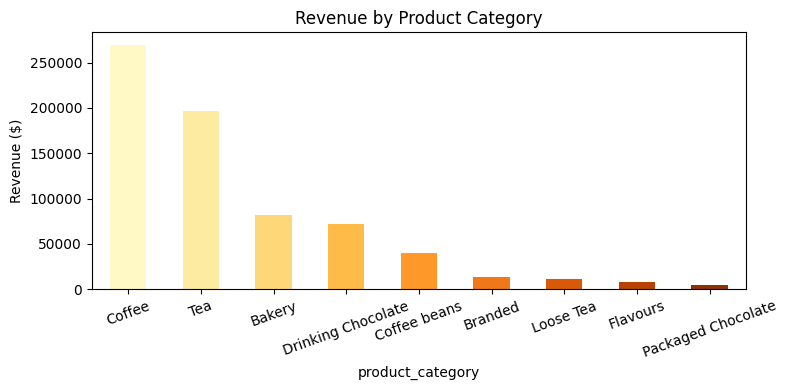

product_category
Coffee                269952.45
Tea                   196405.95
Bakery                 82315.64
Drinking Chocolate     72416.00
Coffee beans           40085.25
Branded                13607.00
Loose Tea              11213.60
Flavours                8408.80
Packaged Chocolate      4407.64
Name: revenue, dtype: float64


In [13]:
#product category breakdown
cat_rev = df.groupby('product_category')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,4))
cat_rev.plot(kind='bar', color=sns.color_palette('YlOrBr', len(cat_rev)))
plt.title('Revenue by Product Category')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('data/category_revenue.png')
plt.show()

print(cat_rev)

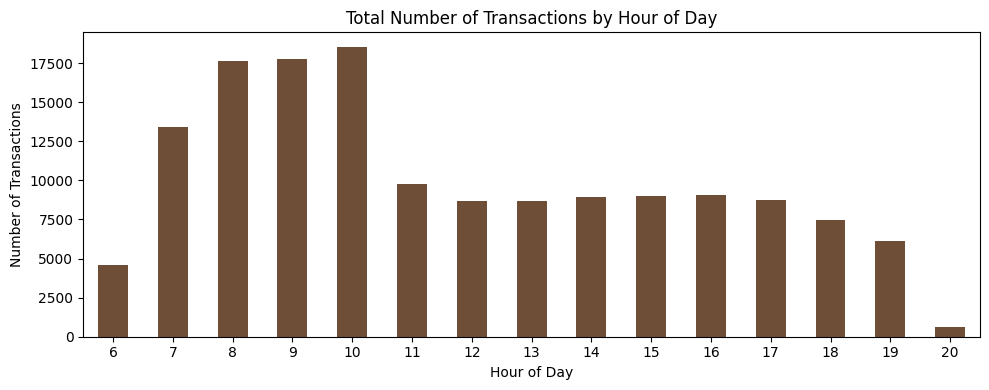

Peak Hour: 10
Transactions at peak: 18545

All hours:
 hour
6      4594
7     13428
8     17654
9     17764
10    18545
11     9766
12     8708
13     8714
14     8933
15     8979
16     9093
17     8745
18     7498
19     6092
20      603
Name: transaction_id, dtype: int64


In [16]:
#count of transactions per hour
hourly_count = df.groupby('hour')['transaction_id'].count()
plt.figure(figsize=(10,4))
hourly_count.plot(kind='bar', color='#6F4E37')
plt.title('Total Number of Transactions by Hour of Day')
plt.ylabel('Number of Transactions')
plt.xlabel('Hour of Day')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Peak Hour:", hourly_count.idxmax())
print("Transactions at peak:", hourly_count.max())
print("\nAll hours:\n", hourly_count)